Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import time
import os

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version", tf.__version__)

TensorFlow version 2.20.0


Mount Google drive


In [ ]:
from google.colab import drive
import pandas as pd
import os

drive.mount('/content/drive')

file_path = '/content/drive/Shareddrives/5841 - Final Project/Sample_Data_1.xlsx'

print("Using file:", file_path)
print("File exists:", os.path.exists(file_path))

sheets = pd.read_excel(file_path, sheet_name=None)

for name, sheet in sheets.items():
    print("\nSheet:", name)
    print("Shape:", sheet.shape)
    print(sheet.head())

# 3. Select working sheet
df = pd.read_excel(file_path, sheet_name="Sheet1")

print(df.head())
print(df.columns)
print(df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using file: /content/drive/Shareddrives/5841 - Final Project/Sample_Data_1.xlsx
File exists: True

Sheet: Sheet1
Shape: (2501, 8)
   Sample 2  Expected  Unnamed: 2  Unnamed: 3  Unnamed: 4  Unnamed: 5  \
0  2.465201  2.445942         NaN         NaN         NaN         NaN   
1  2.148962  2.445942         NaN         NaN         NaN         NaN   
2  2.467643  2.445942         NaN         NaN         NaN         NaN   
3  2.467643  2.445942         NaN         NaN         NaN         NaN   
4  2.466422  2.445942         NaN         NaN         NaN         NaN   

   Unnamed: 6  ExpectedA  
0         NaN   2.467643  
1         NaN   2.465201  
2         NaN   2.465201  
3         NaN   2.465201  
4         NaN   2.462759  

Sheet: Sheet2
Shape: (10798, 14)
   Sample 2  Expected  Unnamed: 2  Unnamed: 3  Unnamed: 4  Expected.1  \
0  2.465201  2.467643         NaN

Clean column names and select signals

In [ ]:
# ============================================
# 4. Select columns
# ============================================

df.columns = df.columns.astype(str).str.strip()

NOISY_COL = "Sample 2"
TARGET_COL = "Expected"

df = df[[NOISY_COL, TARGET_COL]].copy()
df.columns = ["noisy", "expected"]

df["noisy"] = pd.to_numeric(df["noisy"], errors="coerce")
df["expected"] = pd.to_numeric(df["expected"], errors="coerce")

df = df.dropna().reset_index(drop=True)

print(df.head())
print(df.describe())

      noisy  expected
0  2.465201  2.445942
1  2.148962  2.445942
2  2.467643  2.445942
3  2.467643  2.445942
4  2.466422  2.445942
             noisy      expected
count  2501.000000  2.501000e+03
mean      2.445942  2.445942e+00
std       0.069662  9.017178e-14
min       2.026862  2.445942e+00
25%       2.463980  2.445942e+00
50%       2.465201  2.445942e+00
75%       2.466422  2.445942e+00
max       2.637362  2.445942e+00


Plot the raw signal

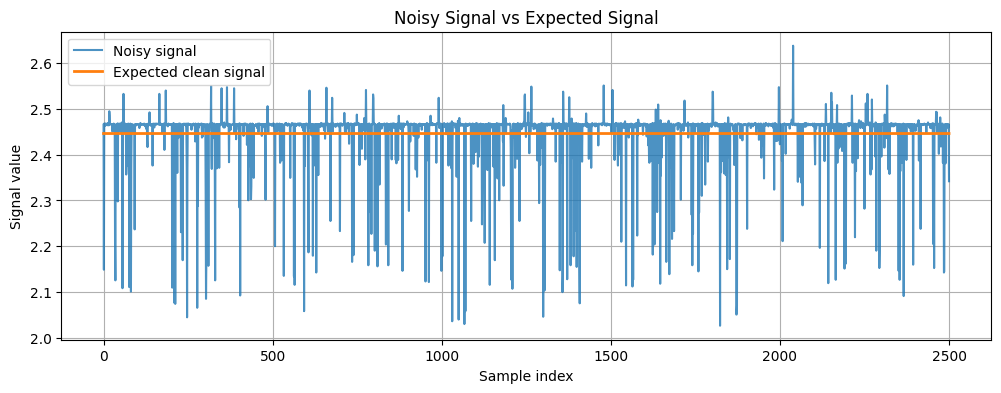

In [ ]:
# ============================================
# 5. Plot noisy vs expected signal
# ============================================

plt.figure(figsize=(12, 4))
plt.plot(df["noisy"].values, label="Noisy signal", alpha=0.8)
plt.plot(df["expected"].values, label="Expected clean signal", linewidth=2)
plt.xlabel("Sample index")
plt.ylabel("Signal value")
plt.title("Noisy Signal vs Expected Signal")
plt.legend()
plt.grid(True)
plt.show()

Baseline Error before modeling

In [ ]:
# ============================================
# 6. Raw baseline metrics
# ============================================

def regression_metrics(y_true, y_pred, label="Model"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"{label}")
    print(f"  MSE : {mse:.8f}")
    print(f"  RMSE: {rmse:.8f}")
    print(f"  MAE : {mae:.8f}")

    return {"mse": mse, "rmse": rmse, "mae": mae}

y_true_raw = df["expected"].values
y_noisy_raw = df["noisy"].values

raw_metrics = regression_metrics(y_true_raw, y_noisy_raw, label="Raw noisy signal")

Raw noisy signal
  MSE : 0.00485090
  RMSE: 0.06964840
  MAE : 0.03576342


Add simple classical baselines

Moving Average window=5
  MSE : 0.00113945
  RMSE: 0.03375575
  MAE : 0.02484626
Moving Average window=15
  MSE : 0.00039104
  RMSE: 0.01977464
  MAE : 0.01611755


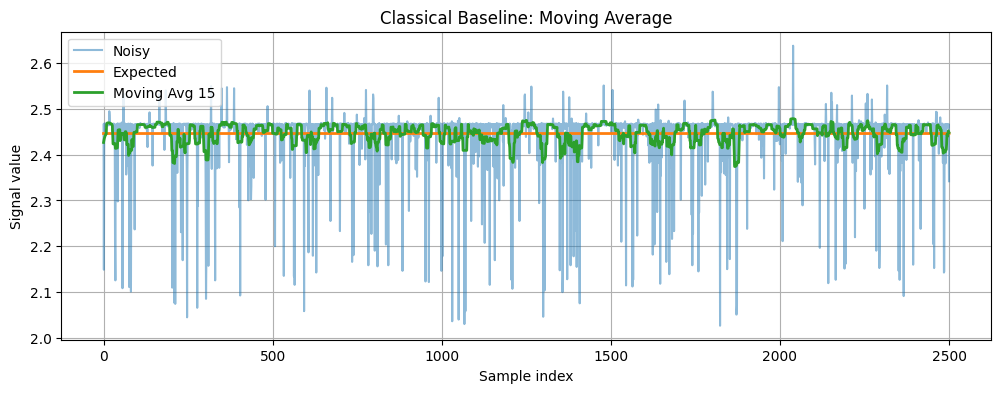

In [ ]:
# ============================================
# 7. Moving average baseline
# ============================================

df["moving_avg_5"] = df["noisy"].rolling(window=5, center=True, min_periods=1).mean()
df["moving_avg_15"] = df["noisy"].rolling(window=15, center=True, min_periods=1).mean()

ma5_metrics = regression_metrics(df["expected"], df["moving_avg_5"], label="Moving Average window=5")
ma15_metrics = regression_metrics(df["expected"], df["moving_avg_15"], label="Moving Average window=15")

plt.figure(figsize=(12, 4))
plt.plot(df["noisy"].values, label="Noisy", alpha=0.5)
plt.plot(df["expected"].values, label="Expected", linewidth=2)
plt.plot(df["moving_avg_15"].values, label="Moving Avg 15", linewidth=2)
plt.xlabel("Sample index")
plt.ylabel("Signal value")
plt.title("Classical Baseline: Moving Average")
plt.legend()
plt.grid(True)
plt.show()

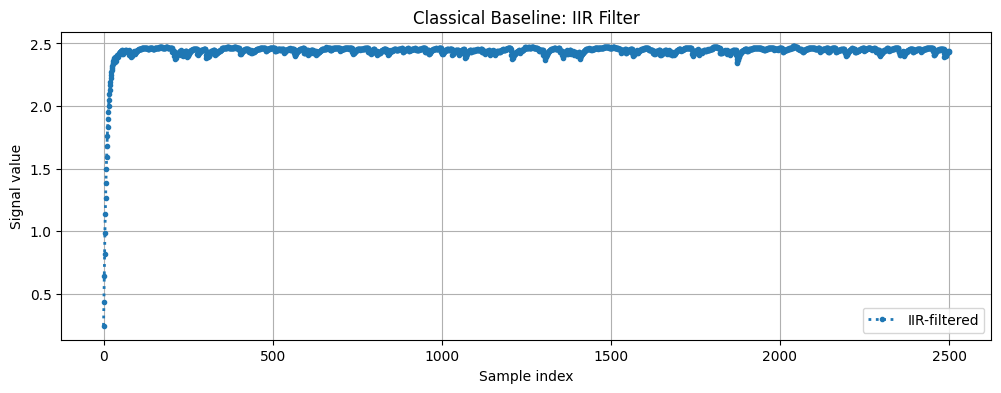

In [ ]:
# ============================================
# 7.1 IIR Filter
# Shown in (Haslwanter, 2021)
# ============================================
from scipy import signal

alpha = 0.1
# IIR filter coefficients for exponential averaging filter
a = [1, -(1-alpha)]
b = [alpha]

data ={}
data['after_iir'] = signal.lfilter(b, a, y_noisy_raw)


df["moving_avg_5"] = df["noisy"].rolling(window=5, center=True, min_periods=1).mean()
df["moving_avg_15"] = df["noisy"].rolling(window=15, center=True, min_periods=1).mean()

ma5_metrics = regression_metrics(df["expected"], df["moving_avg_5"], label="Moving Average window=5")
ma15_metrics = regression_metrics(df["expected"], df["moving_avg_15"], label="Moving Average window=15")



plt.figure(figsize=(12, 4))
plt.plot(data['after_iir'], '.:', label='IIR-filtered', lw=2)
plt.xlabel("Sample index")
plt.ylabel("Signal value")
plt.title("Classical Baseline: IIR Filter")
plt.legend()
plt.grid(True)
plt.show()



Create windowed data

In [ ]:
# ============================================
# 8. Create sliding windows
# ============================================

def create_windows(noisy, expected, window_size=32):
    X = []
    y_correction = []
    y_clean = []
    current_noisy = []

    for i in range(window_size - 1, len(noisy)):
        window = noisy[i - window_size + 1 : i + 1]

        correction = expected[i] - noisy[i]

        X.append(window)
        y_correction.append(correction)
        y_clean.append(expected[i])
        current_noisy.append(noisy[i])

    X = np.array(X)
    y_correction = np.array(y_correction)
    y_clean = np.array(y_clean)
    current_noisy = np.array(current_noisy)

    return X, y_correction, y_clean, current_noisy

WINDOW_SIZE = 32

X, y_corr, y_clean, current_noisy = create_windows(
    df["noisy"].values,
    df["expected"].values,
    window_size=WINDOW_SIZE
)

print("X shape:", X.shape)
print("Correction target shape:", y_corr.shape)
print("Clean target shape:", y_clean.shape)

X shape: (2470, 32)
Correction target shape: (2470,)
Clean target shape: (2470,)


Train / validation / test split

In [ ]:
# ============================================
# 9. Chronological train/val/test split
# ============================================

n = len(X)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train = X[:train_end]
X_val = X[train_end:val_end]
X_test = X[val_end:]

y_train = y_corr[:train_end]
y_val = y_corr[train_end:val_end]
y_test = y_corr[val_end:]

clean_train = y_clean[:train_end]
clean_val = y_clean[train_end:val_end]
clean_test = y_clean[val_end:]

noisy_train = current_noisy[:train_end]
noisy_val = current_noisy[train_end:val_end]
noisy_test = current_noisy[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (1729, 32) (1729,)
Val:   (370, 32) (370,)
Test:  (371, 32) (371,)


Scale the data correctly

In [ ]:
# ============================================
# 10. Scaling
# ============================================

x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Flatten windows for scaling
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

X_train_s = x_scaler.fit_transform(X_train_flat)
X_val_s = x_scaler.transform(X_val_flat)
X_test_s = x_scaler.transform(X_test_flat)

y_train_s = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_s = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_s = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

print("Scaled X train:", X_train_s.shape)
print("Scaled y train:", y_train_s.shape)

Scaled X train: (1729, 32)
Scaled y train: (1729,)


Model 1: DNN / MLP residual model

In [ ]:
# ============================================
# 11. Build DNN / MLP model
# ============================================

def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)  # predicted correction
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=[
            keras.metrics.RootMeanSquaredError(name="rmse"),
            keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    return model

mlp_model = build_mlp(X_train_s.shape[1])
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,385 (32.75 KB)

 Trainable params: 8,385 (32.75 KB)

 Non-trainable params: 0 (0.00 B)

Training above model

In [ ]:
# ============================================
# 12. Train MLP
# ============================================

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=25,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-6
    )
]

history_mlp = mlp_model.fit(
    X_train_s,
    y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=300,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.7848 - mae: 0.4774 - rmse: 0.8859 - val_loss: 0.2463 - val_mae: 0.2895 - val_rmse: 0.4963 - learning_rate: 0.0010
Epoch 2/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1568 - mae: 0.2555 - rmse: 0.3960 - val_loss: 0.0856 - val_mae: 0.1864 - val_rmse: 0.2926 - learning_rate: 0.0010
Epoch 3/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0618 - mae: 0.1719 - rmse: 0.2486 - val_loss: 0.0659 - val_mae: 0.1606 - val_rmse: 0.2567 - learning_rate: 0.0010
Epoch 4/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0410 - mae: 0.1422 - rmse: 0.2025 - val_loss: 0.0548 - val_mae: 0.1418 - val_rmse: 0.2342 - learning_rate: 0.0010
Epoch 5/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0297 - mae: 0.1220 - rmse: 0.1723 - val_loss: 0.0503 - val_mae: 0.1362 - val_rmse: 0.2243 - learning_rate: 0.0010
Epoch 6/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0233 - mae: 0.1093 - rmse: 0.1527 - val_loss: 0.0460 - val_mae:

Evaluate MLP

In [ ]:
# ============================================
# 13. Evaluate MLP
# ============================================

def evaluate_residual_model(model, X_s, noisy_current, y_clean_true, y_scaler, label):
    pred_corr_s = model.predict(X_s, verbose=0).reshape(-1, 1)
    pred_corr = y_scaler.inverse_transform(pred_corr_s).ravel()

    pred_clean = noisy_current + pred_corr

    metrics = regression_metrics(y_clean_true, pred_clean, label=label)

    return pred_clean, pred_corr, metrics

mlp_pred_clean, mlp_pred_corr, mlp_metrics = evaluate_residual_model(
    mlp_model,
    X_test_s,
    noisy_test,
    clean_test,
    y_scaler,
    label="MLP residual model"
)

MLP residual model
  MSE : 0.00005299
  RMSE: 0.00727940
  MAE : 0.00492511


Plot Results

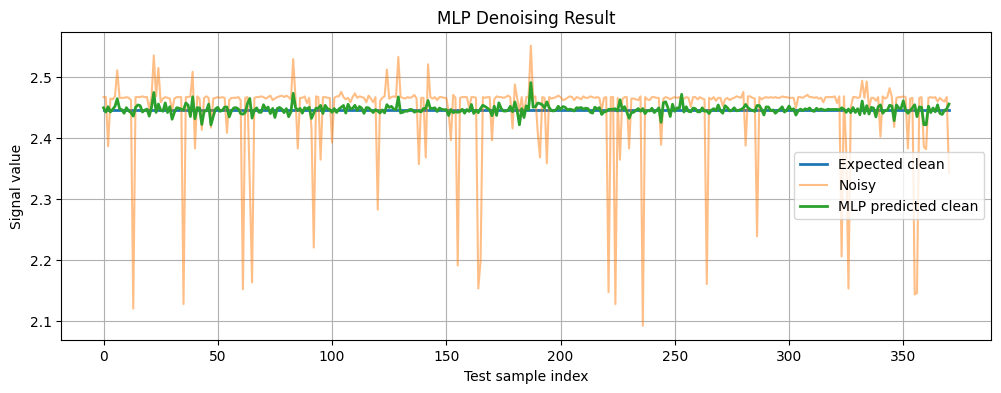

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(clean_test, label="Expected clean", linewidth=2)
plt.plot(noisy_test, label="Noisy", alpha=0.5)
plt.plot(mlp_pred_clean, label="MLP predicted clean", linewidth=2)
plt.xlabel("Test sample index")
plt.ylabel("Signal value")
plt.title("MLP Denoising Result")
plt.legend()
plt.grid(True)
plt.show()

Model 2: Lightweight 1D CNN

In [ ]:
# ============================================
# 14. Prepare data for 1D CNN
# ============================================

X_train_cnn = X_train_s.reshape(X_train_s.shape[0], WINDOW_SIZE, 1)
X_val_cnn = X_val_s.reshape(X_val_s.shape[0], WINDOW_SIZE, 1)
X_test_cnn = X_test_s.reshape(X_test_s.shape[0], WINDOW_SIZE, 1)

print(X_train_cnn.shape)

(1729, 32, 1)


Build Model

In [ ]:
# ============================================
# 15. Build lightweight 1D CNN
# ============================================

def build_1d_cnn(window_size):
    inputs = keras.Input(shape=(window_size, 1))

    x = layers.Conv1D(16, kernel_size=3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(32, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(32, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1)(x)  # predicted correction

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=[
            keras.metrics.RootMeanSquaredError(name="rmse"),
            keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    return model

cnn_model = build_1d_cnn(WINDOW_SIZE)
cnn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 32, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 32, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 16, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 16, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 5,921 (23.13 KB)

 Non-trainable params: 96 (384.00 B)

Train Model 2

In [ ]:
# ============================================
# 16. Train 1D CNN
# ============================================

history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train_s,
    validation_data=(X_val_cnn, y_val_s),
    epochs=300,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 0.8293 - mae: 0.4803 - rmse: 0.9106 - val_loss: 0.6632 - val_mae: 0.4541 - val_rmse: 0.8144 - learning_rate: 0.0010
Epoch 2/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2840 - mae: 0.2923 - rmse: 0.5329 - val_loss: 0.6077 - val_mae: 0.4762 - val_rmse: 0.7795 - learning_rate: 0.0010
Epoch 3/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0773 - mae: 0.1754 - rmse: 0.2780 - val_loss: 0.5640 - val_mae: 0.4662 - val_rmse: 0.7510 - learning_rate: 0.0010
Epoch 4/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0527 - mae: 0.1416 - rmse: 0.2296 - val_loss: 0.5051 - val_mae: 0.4240 - val_rmse: 0.7107 - learning_rate: 0.0010
Epoch 5/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0401 - mae: 0.1217 - rmse: 0.2002 - val_loss: 0.4213 - val_mae: 0.3593 - val_rmse: 0.6490 - learning_rate: 0.0010
Epoch 6/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0343 - mae: 0.1113 - rmse: 0.1853 - val_loss: 0.3390 - val_mae:

Plot Model 2

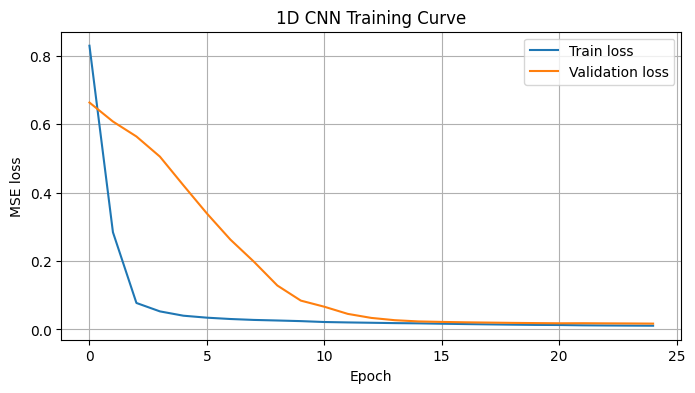

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history_cnn.history["loss"], label="Train loss")
plt.plot(history_cnn.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("1D CNN Training Curve")
plt.legend()
plt.grid(True)
plt.show()

Evaluate Model 2

1D CNN residual model
  MSE : 0.00445708
  RMSE: 0.06676134
  MAE : 0.03843077


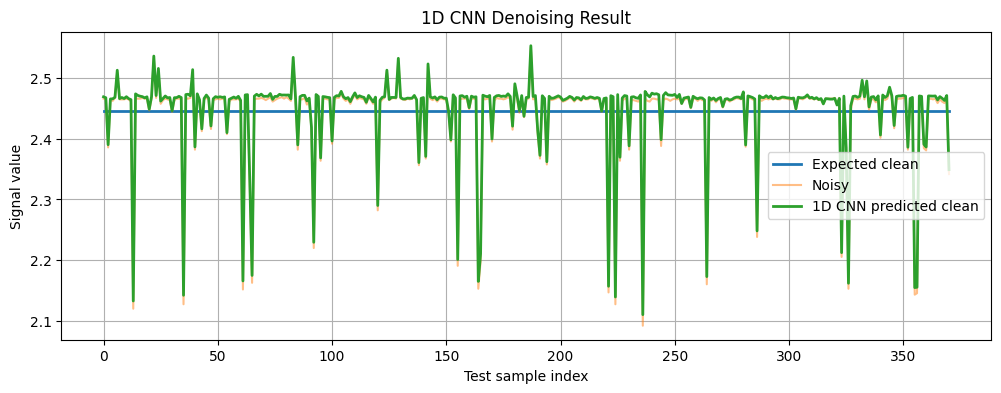

In [ ]:
# ============================================
# 17. Evaluate 1D CNN
# ============================================

cnn_pred_clean, cnn_pred_corr, cnn_metrics = evaluate_residual_model(
    cnn_model,
    X_test_cnn,
    noisy_test,
    clean_test,
    y_scaler,
    label="1D CNN residual model"
)

plt.figure(figsize=(12, 4))
plt.plot(clean_test, label="Expected clean", linewidth=2)
plt.plot(noisy_test, label="Noisy", alpha=0.5)
plt.plot(cnn_pred_clean, label="1D CNN predicted clean", linewidth=2)
plt.xlabel("Test sample index")
plt.ylabel("Signal value")
plt.title("1D CNN Denoising Result")
plt.legend()
plt.grid(True)
plt.show()

Compare All models

In [ ]:
# ============================================
# 18. Model comparison
# ============================================

comparison = pd.DataFrame([
    {"Model": "Raw noisy signal", **regression_metrics(clean_test, noisy_test, "Raw noisy test")},
    {"Model": "MLP residual model", **mlp_metrics},
    {"Model": "1D CNN residual model", **cnn_metrics},
])

comparison

Raw noisy test
  MSE : 0.00467953
  RMSE: 0.06840708
  MAE : 0.03647030


,Model,mse,rmse,mae
0,Raw noisy signal,0.004680,0.068407,0.036470
1,MLP residual model,0.000053,0.007279,0.004925
2,1D CNN residual model,0.004457,0.066761,0.038431


SNR Improvement

In [ ]:
# ============================================
# 19. SNR improvement
# ============================================

def snr_db(clean, estimate):
    noise = clean - estimate
    signal_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)
    return 10 * np.log10(signal_power / noise_power)

raw_snr = snr_db(clean_test, noisy_test)
mlp_snr = snr_db(clean_test, mlp_pred_clean)
cnn_snr = snr_db(clean_test, cnn_pred_clean)

print(f"Raw noisy SNR: {raw_snr:.2f} dB")
print(f"MLP SNR:       {mlp_snr:.2f} dB")
print(f"1D CNN SNR:    {cnn_snr:.2f} dB")

print(f"MLP improvement:    {mlp_snr - raw_snr:.2f} dB")
print(f"1D CNN improvement: {cnn_snr - raw_snr:.2f} dB")

Raw noisy SNR: 31.07 dB
MLP SNR:       50.53 dB
1D CNN SNR:    31.28 dB
MLP improvement:    19.46 dB
1D CNN improvement: 0.21 dB


Measure inference time

In [ ]:
# ============================================
# 20. Inference time test
# ============================================

def measure_inference_time(model, X_sample, repeats=1000):
    # warmup
    _ = model.predict(X_sample[:1], verbose=0)

    start = time.time()

    for _ in range(repeats):
        _ = model.predict(X_sample[:1], verbose=0)

    end = time.time()

    avg_time = (end - start) / repeats

    print(f"Average inference time: {avg_time * 1000:.4f} ms per sample")

    return avg_time

print("MLP inference time:")
mlp_time = measure_inference_time(mlp_model, X_test_s, repeats=100)

print("1D CNN inference time:")
cnn_time = measure_inference_time(cnn_model, X_test_cnn, repeats=100)

MLP inference time:
Average inference time: 65.2098 ms per sample
1D CNN inference time:
Average inference time: 80.5116 ms per sample


Save Best Model

In [ ]:
# ============================================
# 21. Save best model
# ============================================

from google.colab import files

best_model = mlp_model
best_name = "mlp_residual_denoiser"

best_model.save(f"{best_name}.keras")

print("Saved model:", f"{best_name}.keras")

Saved model: mlp_residual_denoiser.keras


Download Best Model

In [ ]:
from google.colab import files
files.download(f"{best_name}.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Convert to TF Lite

In [ ]:
# ============================================
# 22. Convert to TensorFlow Lite
# ============================================

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

with open(f"{best_name}.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model size:", os.path.getsize(f"{best_name}.tflite"), "bytes")

files.download(f"{best_name}.tflite")

Saved artifact at '/tmp/tmp2jporjfj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132293483050192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132293651146768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132293171018064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132293171018448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132293171017872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132293171016144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132293171019024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132293171018640: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model size: 35796 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Optional quantized version

In [ ]:
# ============================================
# 23. Quantized TFLite model
# ============================================

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_quant_model = converter.convert()

with open(f"{best_name}_quant.tflite", "wb") as f:
    f.write(tflite_quant_model)

print("Quantized TFLite model size:", os.path.getsize(f"{best_name}_quant.tflite"), "bytes")

files.download(f"{best_name}_quant.tflite")

Saved artifact at '/tmp/tmpldgiueli'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132293483050192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132293651146768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132293171018064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132293171018448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132293171017872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132293171016144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132293171019024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132293171018640: TensorSpec(shape=(), dtype=tf.resource, name=None)
Quantized TFLite model size: 13200 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# 23. Configure TFLite model for use with STM32
# Creates header file
# ============================================

# Model configuration
MODEL_FILE_NAME = best_name
C_HEADER_DIR = "./" # Output directory for generated files

# Breaking the byte in several lines to fit better in the c header file
tflite_model_split_line = np.array_split([format(hex_value, '#04x') for hex_value in tflite_model], len(tflite_model)//8)

# Write TfLite model to a C header file
open(f"{C_HEADER_DIR}{MODEL_FILE_NAME.lower()}.h", "w").write(
f"""
#ifndef {MODEL_FILE_NAME.upper()}_H
#define {MODEL_FILE_NAME.upper()}_H

const unsigned int {MODEL_FILE_NAME.lower()}_len = {len(tflite_model)};

const unsigned char {MODEL_FILE_NAME.lower()}[{len(tflite_model)}] = {{
    {",\n    ".join([", ".join(line) for line in tflite_model_split_line])}
}};

#endif // {MODEL_FILE_NAME.upper()}_H
"""
)

232883